# Libraries

In [1]:

import torch
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
import pandas as pd
import plotly.express as px
from ignite.handlers import EarlyStopping
from enum import Enum
import plotly.graph_objects as go
import math
import glob
import os
import random


In [2]:
seed = 42

In [3]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    g = torch.Generator(device='cpu')  # MPS backend doesn't use CUDA generators
    g.manual_seed(seed)
    return g

In [4]:
trainset = torchvision.datasets.MNIST(root="deeplearning/MNIST/",train=True,download=True) # downloading the dataset, unscaled and unnormalised for data exploration
testset = torchvision.datasets.MNIST(root="deeplearning/MNIST/",train=False,download=True)

print(f"Trainset size: {len(trainset)}") #checking amount of training data
print(f"Testset size: {len(testset)}") # checking amount of test data

Trainset size: 60000
Testset size: 10000


# Data exploration

In [5]:
def distribution(dataset):
    data = {'one':0 ,'two':0,'three':0,'four':0,'five':0,'six':0,'seven':0,'eight':0,'nine':0,'zero':0}
    
    for i in dataset:
        match i[1]:
            case 0:
                data['zero'] += 1
            case 1:
                data['one'] += 1
            case 2:
                data['two'] += 1
            case 3:
                data['three'] += 1
            case 4:
                data['four'] += 1
            case 5:
                data['five'] += 1
            case 6:
                data['six'] += 1
            case 7:
                data['seven'] += 1
            case 8:
                data['eight'] += 1
            case 9:
                data['nine'] += 1
    return data

In [6]:
# data distribution check
train_data_distribution = distribution(trainset)
test_data_distribution = distribution(testset)
print(f"Train data distribution: {train_data_distribution}")
print(f"Test data distribution: {test_data_distribution}")


Train data distribution: {'one': 6742, 'two': 5958, 'three': 6131, 'four': 5842, 'five': 5421, 'six': 5918, 'seven': 6265, 'eight': 5851, 'nine': 5949, 'zero': 5923}
Test data distribution: {'one': 1135, 'two': 1032, 'three': 1010, 'four': 982, 'five': 892, 'six': 958, 'seven': 1028, 'eight': 974, 'nine': 1009, 'zero': 980}


In [7]:
#Plot the distributions using plotly
train_dist_df = pd.DataFrame(
    data=list(train_data_distribution.items()),
    columns=pd.Index(['Digit','Count'])
)


test_dist_df = pd.DataFrame(
    data=list(test_data_distribution.items()),
    columns=pd.Index(['Digit','Count'])
)
# %%


In [8]:
fig = px.bar(train_dist_df, x='Digit', y='Count', title='Train Data Distribution')
fig.show()

fig = px.bar(test_dist_df, x='Digit', y='Count', title='Test Data Distribution')
fig.show()

# %%


In [9]:

number= trainset[0][0] # slicing for first image
number_label = trainset[0][1] #Slicing for first image lable
print(f"image size: {number.size}") #checking number size
print(f"image:{number}") # getting the images info
print(f"label: {number_label}") # checking label format and correct loading
print(f"image mode: {number.mode}") #mode shows reveals channels
print(f"image dtype: {type(number)}") #checking type


#The mode of an image is a string which defines the type and depth of a pixel in the image.
# Each pixel uses the full range of the bit depth. L (8-bit pixels, grayscale)

# %%


image size: (28, 28)
image:<PIL.Image.Image image mode=L size=28x28 at 0x31F09BDD0>
label: 5
image mode: L
image dtype: <class 'PIL.Image.Image'>


In [10]:

number = v2.ToImage()(number)
number.shape
# Has to be transformed into a tensor image first, check transfomer variable  and type deafults to dtype=torch.uint8/ float 32 but we will still specify
# new shape becomes 1, 28,28 : channel, height, width
# An MNIST image is stored as a 28x28 tensor (28 rows, 28 columns of pixels).
# Each entry in the matrix is a pixel intensity value (0–1 after scaling).
# When flattened, this 28x28 = 784 values, which form the input vector for an MLP.
print(number)
# %%


Image([[[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [11]:

print(f"min pixel value: {torch.min(number)}")
print(f"max pixel value: {torch.max(number)}")


min pixel value: 0
max pixel value: 255


# Mean STD imputer

In [12]:
#When working with very large datasets, compute mean/std on a cleaned, representative random sample (scaled to [0,1]),
#then lock those values in for normalization — this preserves stability without the cost of scanning the entire dataset.

def std_mean_computer(trainset):
    # only for greyscale/single channel images, if image is RGB then mean and sted have to be calculated for all channels
    transformer =v2.Compose([
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float,scale=True)]
        )
    # Scaling division to 255 regard regardless of channels.
    #it’s about bringing the numeric range into a stable interval (usually [0,1]).
    #This preserves all the visual information while making optimization more efficient and numerically stable.
    trainset.transform = transformer
    loader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=False, num_workers=0)

    avg_mean = 0.
    avg_std = 0.
    n = 0

    for imgs, _ in loader:#"_" is used as a throwaway variable name in Python to mean “I acknowledge there’s a second value here, but I’m not going to use it. could write "for imgs, labels”
        batch_samples = imgs.size(0) #imgs is shape [batch, channels, height, width] geting the first element gives us the amount of images
        imgs = imgs.view(batch_samples, -1) #flattens each image into a single vector sets the basis for std and mean calculation, Now each image is a row vector, shape [512, 784].
        avg_mean += imgs.mean(1).sum()# mean(1): per-image mean across pixels → [batch_size]784
                                     # sum(): total of all per-image means in this batch
                                     # accumulate into running sum of means
        avg_std += imgs.std(1).sum()# std(1): per-image std across pixels → [batch_size]
                                 # sum(): total of all per-image stds in this batch
                                 # accumulate into running sum of stds
        n += batch_samples

    avg_mean /= n
    avg_std /= n

    print("Mean:", avg_mean)
    print("Std:", avg_std)
    print(f'Images processed: {n}')
    return avg_mean, avg_std

In [13]:
std_mean_computer(trainset)

Mean: tensor(0.1307)
Std: tensor(0.3015)
Images processed: 60000


(tensor(0.1307), tensor(0.3015))

In [14]:
# Normalizing based on computed mean and std

avgmean, avgstd = std_mean_computer(trainset) # getting the averages values outside of the function


Mean: tensor(0.1307)
Std: tensor(0.3015)
Images processed: 60000


# Data LOader

In [15]:

batch_size = 64
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size,shuffle= True,num_workers = 0)
testloader = torch.utils.data.DataLoader(testset, batch_size = batch_size,num_workers = 0)

In [16]:
classes = ('zero','one', 'two', 'three', 'four','five', 'six', 'seven', 'eight', 'nine')
def imshow(img):
    # get some random training images
    dataiter = iter(trainloader)
    images, labels = next(dataiter)

    # Plot images and labels
    fig, axes = plt.subplots(8, 8, figsize=(6, 6))
    axes = axes.ravel()

    for i in range(batch_size):
        # Unnormalize image
        img = images[i] * avgstd + avgmean
        # Normalization:   x_norm = (x - mean) / std
        # - Subtract mean → centers pixel values around 0
        # - Divide by std  → scales values so distribution has unit variance
        # - Helps training by keeping inputs in a stable range

        # Unnormalization: x = x_norm * std + mean
        # - Multiply by std → restore original spread of values
        # - Add mean       → shift back to original brightness range
        # - Used when displaying images after training so they look like the originals

        npimg = img.numpy()

        axes[i].imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
        axes[i].set_title(classes[labels[i]])
        axes[i].axis('off')

    plt.tight_layout()
    plt.show(block=False)

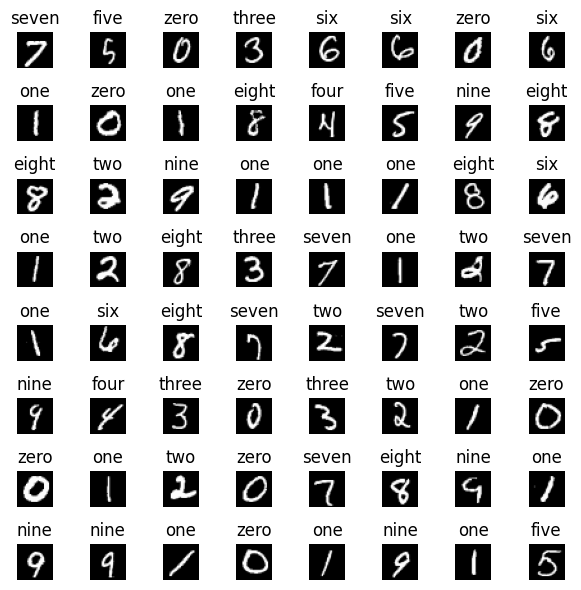

In [17]:
imshow(trainset)

# Models

In [18]:

# Define a Multilayer perceptron network
class Mlp(nn.Module): #defining class mlp that inherits from the nn module
  def __init__(self): #constructor that runs when we create elements of this class
    super().__init__() #calling the parent class(nn) to setup internal stuff
    self.input_layer = nn.Linear(784,128) #attribute
    self.hidden_layer = nn.Linear(128,64) #---"---
    self.output_layer = nn.Linear(64,10)  #---"---

  def forward(self,x): # The forward pass defines how input data flows through the layers and activations
    x = torch.flatten(x,1) #torch.flatten(x, 1) means: Flatten starting at dimension 1 (keep dimension 0 — the batch dimension — untouched).So each image [1, 28, 28] → becomes [784].
                          #leaving the batch dimension untouched since we want multiple images per batch
    x = F.relu(self.input_layer(x)) # y=xWT+b Relu is used to introduce non linearity into the picture,it helps the model learn curved deceision bounderies and not just linear/ straight lines
                                    # this boosts the models abiility to learn complex patterns, without relu, stacking layers would still behave like one linear layer.”
    x = F.relu(self.hidden_layer(x))
    x = self.output_layer(x)
    return x


Shape finder for CNN


In [19]:
#  functions that calculates the output shape of the convolution/pooling layer
def shape_finder(channel,input_H,input_W,kernelsize_or_poolingFilter,stride,padding,dilation):
    match channel:
        case 1:
            if input_H == input_W:
                shape = ((input_H + 2 * padding - dilation * (kernelsize_or_poolingFilter - 1)-1)//stride)+1
                return shape

    # function documentation: some advanced things like diferent size input height and width , where the pooling kernernal might again have W&H different to that of the  tensor 
    #This function follows the current skill level with same H&W values 
        #Kh Kw kernel (window) size: height and width
        #Sh Sw stride: how far the window moves vertically/horizontally
        #Ph,Pw — padding: pixels added around the border (top/bottom, left/right)
        #Dh,Dw — dilation: spacing inside the kernel (default 1)
    #And the tensor shape pieces:
        #C — channels (feature maps)
        #H,W — spatial height and width
        #N — batch size (doesn’t change in these formulas)

In [20]:
input_H = 28
input_W = 28
channel = 1
kernelsize = 3
poolingkernel = 3
stride = 1
poolingstride = 2
padding = 0
dilation = 1

c1 = shape_finder(channel, input_H, input_W, kernelsize, stride, padding, dilation)
print(c1)

p1 = shape_finder(channel, c1, c1, poolingkernel, poolingstride, padding, dilation)
print(p1)

c2 = shape_finder(channel, p1, p1, kernelsize, stride, padding, dilation)
print(c2)

p2 = shape_finder(channel, c2, c2, poolingkernel, poolingstride, padding, dilation)
print(p2)

no_features = 32 * p2 * p2
print(no_features)

26
12
10
4
512


In [21]:
class Cnn(nn.Module):
    def __init__(self):
        super().__init__()
        input_H = 28
        input_W = 28
        channel = 1
        convl1 = [channel,16]
        convl2 = [16,32]
        kernelsize = 3
        poolingkernel = 3
        stride = 1
        poolingstride = 2
        padding = 0
        dilation = 1



        
        self.convlayer1 = nn.Conv2d(convl1[0],convl1[1],kernelsize,stride)
        self.pool1 = nn.MaxPool2d(poolingkernel,poolingstride,padding,dilation)
        self.convlayer2 = nn.Conv2d(convl2[0],convl2[1],kernelsize,stride)
        self.pool2 = nn.MaxPool2d(poolingkernel,poolingstride,padding,dilation)
        
        shape1 = shape_finder(channel,input_H,input_W,kernelsize,stride,padding,dilation)
        shape2 = shape_finder(channel,shape1,shape1,poolingkernel,poolingstride,padding,dilation)
        shape3 = shape_finder(channel,shape2,shape2,kernelsize,stride,padding,dilation)
        x_final = shape_finder(channel,shape3,shape3,poolingkernel,poolingstride,padding,dilation)

        l1 = (convl2[1] * x_final * x_final)
        l2 = 256
        l3 = 128
        output = 10



        self.fc1 = nn.Linear(l1,l2)
        self.fc2 = nn.Linear(l2,l3)
        self.fc3 = nn.Linear(l3,output)

    def forward(self,x):
        x = F.relu(self.convlayer1(x))
        x = self.pool1(x)
        x = F.relu(self.convlayer2(x))
        x = self.pool2(x)

        x = torch.flatten(x,1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

### Configs 

In [22]:
from itertools import product


model_types = ["Mlp", "Cnn"]
optimizers = ["SGD", "Adam", "RMSprop"]
augmentations = ["Rotation", "Distortion", "Inversion"]
all_configs = []

for model in model_types:
    for opt, aug in product(optimizers, augmentations):
        cfg = {
            "model": model,
            "optimizer": opt,
            "augmentation": aug,
        }
        all_configs.append(cfg)


In [23]:
def get_model_name(config: dict, include_run_id: bool = True) -> str:
    """Generate a descriptive model name based on configuration."""
    parts = []

    # Include key fields in a consistent order
    for key in ["model", "optimizer", "augmentation"]:
        value = config.get(key)
        if value:
            parts.append(str(value))

    return "_".join(parts).replace("/", "-")

In [24]:
all_configs

[{'model': 'Mlp', 'optimizer': 'SGD', 'augmentation': 'Rotation'},
 {'model': 'Mlp', 'optimizer': 'SGD', 'augmentation': 'Distortion'},
 {'model': 'Mlp', 'optimizer': 'SGD', 'augmentation': 'Inversion'},
 {'model': 'Mlp', 'optimizer': 'Adam', 'augmentation': 'Rotation'},
 {'model': 'Mlp', 'optimizer': 'Adam', 'augmentation': 'Distortion'},
 {'model': 'Mlp', 'optimizer': 'Adam', 'augmentation': 'Inversion'},
 {'model': 'Mlp', 'optimizer': 'RMSprop', 'augmentation': 'Rotation'},
 {'model': 'Mlp', 'optimizer': 'RMSprop', 'augmentation': 'Distortion'},
 {'model': 'Mlp', 'optimizer': 'RMSprop', 'augmentation': 'Inversion'},
 {'model': 'Cnn', 'optimizer': 'SGD', 'augmentation': 'Rotation'},
 {'model': 'Cnn', 'optimizer': 'SGD', 'augmentation': 'Distortion'},
 {'model': 'Cnn', 'optimizer': 'SGD', 'augmentation': 'Inversion'},
 {'model': 'Cnn', 'optimizer': 'Adam', 'augmentation': 'Rotation'},
 {'model': 'Cnn', 'optimizer': 'Adam', 'augmentation': 'Distortion'},
 {'model': 'Cnn', 'optimizer': 

In [25]:
get_model_name(all_configs[0])

'Mlp_SGD_Rotation'

## device setter

In [26]:
def DeviceCheck():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using GPU:", torch.cuda.get_device_name(0))
    elif torch.backends.mps.is_available(): #checking for macs with M1 chips
        device = torch.device("mps")
        print("Using MPS")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

# ML Pipeline

In [27]:
# function to reset and initialise model
def model_init(model_type):
    device = DeviceCheck()
    match model_type:
        case "mlp":
            model = Mlp()
        case "cnn":
            model = Cnn()
    model.to(device)
    return model

In [28]:
def reset_weights(model):
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()

In [29]:
device = DeviceCheck()

Using MPS


In [30]:
#model initialization
mlp = Mlp()
mlp.to(device)


Mlp(
  (input_layer): Linear(in_features=784, out_features=128, bias=True)
  (hidden_layer): Linear(in_features=128, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=10, bias=True)
)

In [31]:

cnn = Cnn()

cnn.to(device)

Cnn(
  (convlayer1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convlayer2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

## Experiments

In [32]:
# standard model parameters

parameters = {
'best_loss' : 1,
'patience' : 12,
'improvement_threashold' : 0.05,
'patience_counter' : 0,
'epoch_limit' : 100,
'lr' : 0.001,
}

### Augmentation techniques

In [33]:
### Augmentation techniques
rotate = v2.RandomRotation(degrees=15)
invert = v2.RandomInvert(p=0.5)
distort = v2.RandomPhotometricDistort(p=0.5)

### optimizers

#only for testing

In [34]:
mlp_sgd_optimizer = optim.SGD(mlp.parameters(), lr=parameters['lr'], momentum=0.9)
cnn_sgd_optimizer = optim.SGD(cnn.parameters(), lr=parameters['lr'], momentum=0.9)

In [35]:
mlp_adam_optimizer = optim.Adam(mlp.parameters(), lr=parameters['lr'])
cnn_adam_optimizer = optim.Adam(cnn.parameters(), lr=parameters['lr'])

In [36]:
mlp_rmsprop_optimizer = optim.RMSprop(mlp.parameters(), lr=parameters['lr'], momentum=0.9)
cnn_rmsprop_optimizer = optim.RMSprop(cnn.parameters(), lr=parameters['lr'], momentum=0.9)

### lr Schedulers

In [64]:
#only for testing

In [37]:
mlp_sgd_scheduler = optim.lr_scheduler.StepLR(mlp_sgd_optimizer, step_size=5, gamma=0.99)
mlp_adam_scheduler = optim.lr_scheduler.StepLR(mlp_adam_optimizer, step_size=5, gamma=0.99)
mlp_rmsprop_scheduler = optim.lr_scheduler.StepLR(mlp_rmsprop_optimizer, step_size=5, gamma=0.99)

In [38]:
cnn_sgd_scheduler = optim.lr_scheduler.StepLR(cnn_sgd_optimizer, step_size=5, gamma=0.99)
cnn_adam_scheduler = optim.lr_scheduler.StepLR(cnn_adam_optimizer, step_size=5, gamma=0.99)
cnn_rmsprop_scheduler = optim.lr_scheduler.StepLR(cnn_rmsprop_optimizer, step_size=5, gamma=0.99)

### Training/ Validation loop

In [39]:

def train_model(model, trainloader, testloader, criterion, optimizer, scheduler, device, parameters, name_config):
    model_name = get_model_name(name_config)
    best_loss = parameters['best_loss']
    patience = parameters['patience']
    improvement_threashold = parameters['improvement_threashold']
    patience_counter = parameters['patience_counter']
    epoch_limit = parameters['epoch_limit']

    traininglogs = {"epoch": [], "loss": [], "accuracy": [], "lr": []}
    testinglogs = {"epoch": [], "loss": [], "accuracy": [], "lr": []}

    optimizer.zero_grad() # zero the parameter gradients

    for epoch in range(epoch_limit):  # loop over the dataset multiple times
        correct_pred = {classname: 0 for classname in classes}
        total_pred = {classname: 0 for classname in classes}

        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data[0].to(device), data[1].to(device)
            #inputs, labels = data # on cpu!!!


            # forward + backward + optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            optimizer.step()
            optimizer.zero_grad() # zero the parameter gradients


        _, predicted = torch.max(outputs.data, 1)
        total = labels.size(0)
        correct = (predicted == labels).sum().item()
        accuracy = 100 * correct / total
                        


        before_lr = optimizer.param_groups[0]["lr"]

        traininglogs["epoch"].append(epoch)
        traininglogs["loss"].append(loss.item())
        traininglogs["accuracy"].append(accuracy)
        traininglogs["lr"].append(before_lr)
                # print statistics
        correct = 0
        total = 0
        total_loss = 0.0
        avg_loss = 0.0

        
        with torch.no_grad():
            for data in testloader:
                images, labels = data[0].to(device), data[1].to(device)
                # calculate outputs by running images through the network
                outputs = model(images)
                # the class with the highest energy is what we choose as prediction
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                test_loss = criterion(outputs, labels)
                total_loss += test_loss.item()
                avg_loss = total_loss / len(testloader)

                for label, prediction in zip(labels, predicted):
                    if label == prediction:
                        correct_pred[classes[label]] += 1
                    total_pred[classes[label]] += 1

            val_loss = avg_loss
            
            #debug
            print(f'best_loss: {best_loss}')
            if val_loss < best_loss - improvement_threashold : # Early stopping condition
                best_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
            testinglogs["epoch"].append(epoch)
            testinglogs["loss"].append(test_loss.item())
            testinglogs["accuracy"].append(100 * correct / total)
            testinglogs["lr"].append(before_lr)

            

        scheduler.step()
        after_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch: {epoch + 1}, Loss: {val_loss:.3f}, Learning Rate: {before_lr:.6f} -> {after_lr:.6f}")
    print('Finished Training')

    

    # merge training and testing logs for easier plotting
    traininglogs_df = pd.DataFrame(traininglogs)
    testinglogs_df = pd.DataFrame(testinglogs)
    traininglogs = pd.merge(traininglogs_df, testinglogs_df, on="epoch", suffixes=('_train', '_test')).to_dict(orient='list')
    traininglogs = pd.DataFrame(traininglogs)
    traininglogs.reset_index(drop=True, inplace=True)
    # export logs to csv to runs folder
    traininglogs.to_csv(f'runs/{model_name}_logs.csv', index=False)

In [40]:

def print_class_accuracies(correct_pred, total_pred):
    # print accuracy for each class
    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')


In [41]:
criterion = nn.CrossEntropyLoss()

# Experiment loop

In [42]:
def setup_run(config):
    # Models
    # set seed
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    g = torch.Generator(device='cpu')  # MPS backend doesn't use CUDA generators
    g.manual_seed(seed)
    model = Mlp() if config["model"] == "Mlp" else Cnn()
    model.to(DeviceCheck())
    
   # transformers
    match config["augmentation"]:
        case "Rotation":
            rotate = v2.RandomRotation(degrees=15)
            transformer = v2.Compose([
                rotate,
                v2.ToImage(),
                v2.ToDtype(dtype=torch.float32, scale=True),
                v2.Normalize([avgmean], [avgstd])
            ])
        case "Inversion":
            invert = v2.RandomInvert(p=0.7)
            transformer = v2.Compose([
                invert,
                v2.ToImage(),
                v2.ToDtype(dtype=torch.float32, scale=True),
                v2.Normalize([avgmean], [avgstd])
            ])
        case "Distortion":
            distort = v2.RandomPhotometricDistort(p=0.7)
            transformer = v2.Compose([
                distort,
                v2.ToImage(),
                v2.ToDtype(dtype=torch.float32, scale=True),
                v2.Normalize([avgmean], [avgstd])
            ])
        case _:
                raise ValueError(f"Unknown augmentation: {config['augmentation']}")  
        
    

    # Dataset + Loader
    trainset = torchvision.datasets.MNIST(root="", train=True, transform=transformer)
    trainload = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=0, generator=g)
    testset = torchvision.datasets.MNIST(root="", train=False, transform=transformer)
    testload = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=0, generator=g)

    # Optimizer
    lr = config.get("lr", 0.001)
    match config["optimizer"].lower():
        case "sgd":
            optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        case "adam":
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
        case "rmsprop":
            optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, momentum=0.9)
        case _:
            raise ValueError(f"Unknown optimizer: {config['optimizer']}")

    # Scheduler (always StepLR) 
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    

    return model, trainload, testload, optimizer, scheduler


   

In [43]:
for i, config in enumerate(all_configs):
    run_name = get_model_name(config)
    print(f"\n 🦺 [{i+1}/18] Running: {run_name}")

    # Setup model, data, optimizer, scheduler
    model, trainload, testload, optimizer, scheduler = setup_run(config)

    # Reset weights (important!)
    model.apply(reset_weights)

    # Train
    train_model(
        model,
        trainload,
        testload,
        criterion,
        optimizer,
        scheduler,
        device,
        parameters,
        config               # for naming the run
    )


 🦺 [1/18] Running: Mlp_SGD_Rotation
Using MPS
best_loss: 1
Epoch: 1, Loss: 0.401, Learning Rate: 0.001000 -> 0.001000
best_loss: 0.4006108307060163
Epoch: 2, Loss: 0.326, Learning Rate: 0.001000 -> 0.001000
best_loss: 0.32646396613804396
Epoch: 3, Loss: 0.258, Learning Rate: 0.001000 -> 0.001000
best_loss: 0.25775113294292595
Epoch: 4, Loss: 0.234, Learning Rate: 0.001000 -> 0.001000
best_loss: 0.25775113294292595
Epoch: 5, Loss: 0.205, Learning Rate: 0.001000 -> 0.000500
best_loss: 0.20459689510167595
Epoch: 6, Loss: 0.193, Learning Rate: 0.000500 -> 0.000500
best_loss: 0.20459689510167595
Epoch: 7, Loss: 0.181, Learning Rate: 0.000500 -> 0.000500
best_loss: 0.20459689510167595
Epoch: 8, Loss: 0.175, Learning Rate: 0.000500 -> 0.000500
best_loss: 0.20459689510167595
Epoch: 9, Loss: 0.167, Learning Rate: 0.000500 -> 0.000500
best_loss: 0.20459689510167595
Epoch: 10, Loss: 0.163, Learning Rate: 0.000500 -> 0.000250
best_loss: 0.20459689510167595
Epoch: 11, Loss: 0.159, Learning Rate: 0

# Visuals

In [2]:
directory = 'runs'

In [3]:
cnn_data = glob.glob(os.path.join(directory, 'CNN*.csv')) 
mlp_data = glob.glob(os.path.join(directory, 'MLP*.csv'))

In [4]:
cnn_data_col = {}
file_counter=0
for file in cnn_data:
  file_counter += 1
  print(f"on file {file_counter}")
  csvname = os.path.splitext(os.path.basename(file))[0]
  cnn_data_col[csvname] = pd.read_csv(file)

on file 1
on file 2
on file 3
on file 4
on file 5
on file 6
on file 7
on file 8
on file 9


In [5]:
len(cnn_data_col)

9

In [6]:
mlp_data_col = {}
file_counter=0
for file in mlp_data:
    file_counter += 1
    print(f"on file {file_counter}")
    csvname = os.path.splitext(os.path.basename(file))[0]
    mlp_data_col[csvname] = pd.read_csv(file)

on file 1
on file 2
on file 3
on file 4
on file 5
on file 6
on file 7
on file 8
on file 9


In [7]:
len(mlp_data_col)

9

## MLP

### MLP comparing optimizers

In [8]:
mlp_data_col.keys()

dict_keys(['MLP_SGD_Distortion_logs', 'MLP_RMSprop_Rotation_logs', 'MLP_SGD_Inversion_logs', 'MLP_SGD_Rotation_logs', 'MLP_Adam_Inversion_logs', 'MLP_RMSprop_Distortion_logs', 'MLP_Adam_Distortion_logs', 'MLP_Adam_Rotation_logs', 'MLP_RMSprop_Inversion_logs'])

In [9]:
mlp_data_col['MLP_Adam_Distortion_logs']['accuracy_test']

0     95.24
1     95.79
2     97.21
3     96.84
4     97.60
5     97.92
6     98.11
7     97.78
8     98.02
9     98.01
10    98.28
11    98.20
12    97.99
13    98.16
Name: accuracy_test, dtype: float64

In [10]:
# comparing optimzers for mlp

# all optimizers with rotation augmentation
frames = []
for name, table in mlp_data_col.items():
    if "Rotation" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="SGD Rotation")
fig.show()

In [11]:
# comparing optimzers for mlp

# all optimizers with distortion augmentation
frames = []
for name, table in mlp_data_col.items():
    if "Distortion" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="SGD Distortion")
fig.show()

In [12]:
# comparing optimzers for mlp

# all optimizers with inversion augmentation
frames = []
for name, table in mlp_data_col.items():
    if "Inversion" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="SGD Inversion")
fig.show()

### Comparing Augmentation on optimizers techniques 

In [13]:

frames = []
for name, table in mlp_data_col.items():
    if "SGD" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="MLP SGD")
fig.show()

In [14]:
frames = []
for name, table in mlp_data_col.items():
    if "Adam" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="MLP Adam")
fig.show()

In [15]:
frames = []
for name, table in mlp_data_col.items():
    if "RMSprop" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="RMSprop")
fig.show()

## CNN

### Comparing optimizers

In [16]:
frames = []
for name, table in cnn_data_col.items():
    if "Rotation" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="CNN Rotation")
fig.show()

In [17]:
frames = []
for name, table in cnn_data_col.items():
    if "Distortion" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="CNN Distortion")
fig.show()

In [18]:
frames = []
for name, table in cnn_data_col.items():
    if "Inversion" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="CNN Inversion")
fig.show()

### Comparing optimzers for cnn

In [19]:
frames = []
for name, table in cnn_data_col.items():
    if "SGD" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="CNN SGD")
fig.show()

In [20]:
frames = []
for name, table in cnn_data_col.items():
    if "Adam" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="CNN Adam")
fig.show()

In [21]:
frames = []
for name, table in cnn_data_col.items():
    if "RMS" in name:
        frames.append(
            pd.DataFrame({
                'epoch': table['epoch'],
                'accuracy_test': table['accuracy_test'],
                'model': name
            })
        )

fig = px.line(pd.concat(frames), x="epoch", y="accuracy_test", color="model", title="CNN RMSprop")
fig.show()